# Looming Analysis — Example

Minimal usage of the `looming_analysis` package:

1. Load `.braidz` files grouped by experimental condition.
2. Classify trials as responsive / non-responsive.
3. Plot across the parameter space using the `row_by` / `col_by` / `hue_by` API.

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from looming_analysis import (
    process_all_files,
    process_file_groups,
    classify_responsiveness,
    plot_responses,
    plot_heading_changes,
    plot_responsiveness_rates,
    plot_responses_by_responsiveness,
    plot_peak_velocity,
    compute_turn_direction,
    plot_turn_proportions
)

## Single-group analysis

Use `process_all_files` when you have several `.braidz` files from one condition
and just want to compare looming parameters (e.g. `final_size_deg`,
`expansion_duration_ms`, `stimulus_offset_deg`) within that group.

With a single group there is no `hue_by="group"` — instead use all three facet
dimensions for the stimulus parameters themselves.

In [6]:
# Load all files from one condition — no group label needed
root_folder = "/mnt/data/experiments/"
single_responses = process_all_files(
    [
        root_folder + "20260416_145408.braidz",
        root_folder + "20260417_141459.braidz",
        root_folder + "20260418_134805.braidz"
    ],
    pre_frames=-10,
    post_frames=50,
    max_gap_frames=5,
)
classify_responsiveness(single_responses)

Processing /mnt/data/experiments/20260416_145408.braidz...
  extract_responses: 51 stimuli → 44 kept, 7 skipped (no track: 0, too many gaps: 7)
  Extracted 44 valid responses.
Processing /mnt/data/experiments/20260417_141459.braidz...
  extract_responses: 212 stimuli → 179 kept, 33 skipped (no track: 0, too many gaps: 33)
  Extracted 179 valid responses.
Processing /mnt/data/experiments/20260418_134805.braidz...
  extract_responses: 220 stimuli → 182 kept, 38 skipped (no track: 0, too many gaps: 38)
  Extracted 182 valid responses.


[{'ang_vel': array([ -5.21247955,  -7.86985997, -11.13309427, -14.63875794,
         -16.93441519, -17.64799517, -17.16199372, -15.95375175,
         -14.47201292, -13.24500827, -12.64010237, -12.44028554,
         -11.85511001, -10.10811099,  -7.05996185,  -3.26354339,
           0.58534376,   4.12809055,   7.12266529,   8.98507238,
           9.08498612,   7.53300837,   5.22678014,   3.06051466,
           1.40660178,   0.37806789,   0.25944959,   1.38809496,
           3.60226007,   6.05996189,   7.80241933,   8.4309286 ,
           8.13501505,   7.18863389,   5.67453568,   3.72726496,
           1.74213908,   0.16981114,  -0.75859137,  -1.05873125,
          -0.86229325,  -0.28170167,   0.63407766,   1.86557414,
           3.43708502,   5.41906353,   7.80307105,  10.41004989,
          12.9069873 ,  14.78662619,  15.40105891,  14.31844355,
          11.82610785,   8.85502583,   6.20724552,   4.1582362 ,
           2.86053697,   2.49833023,   2.84803737,   3.41272584]),
  'heading_c

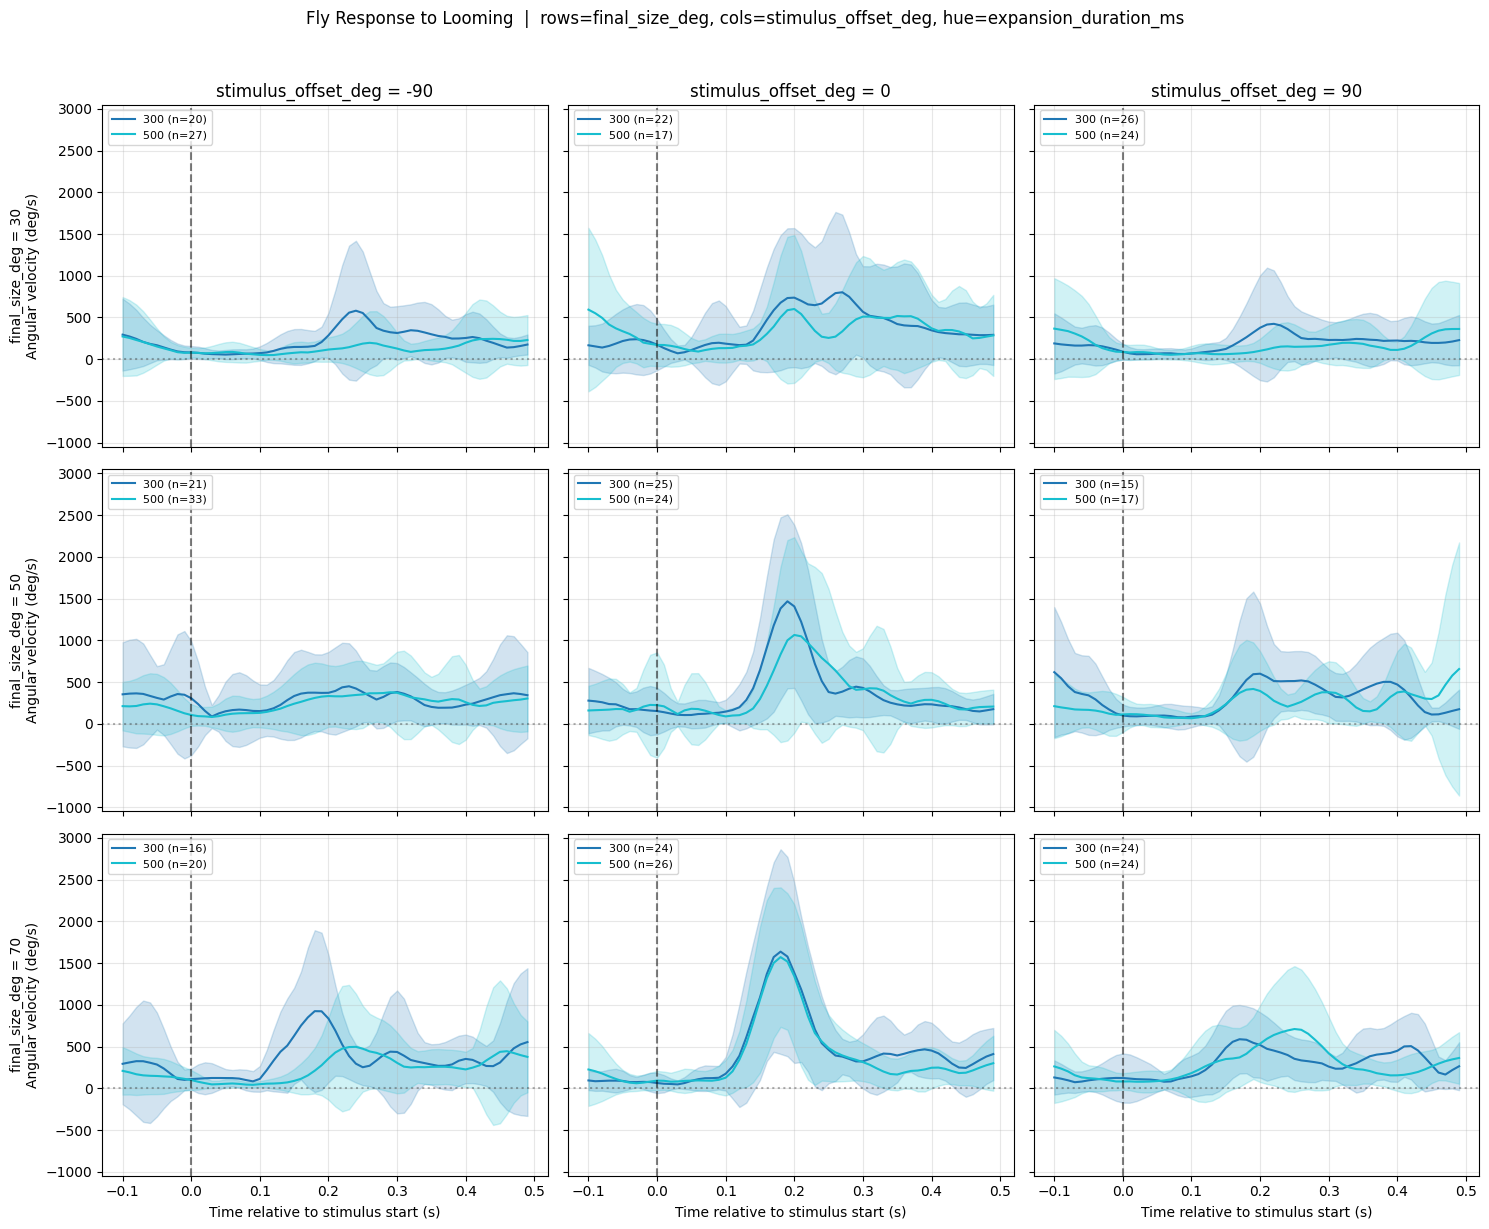

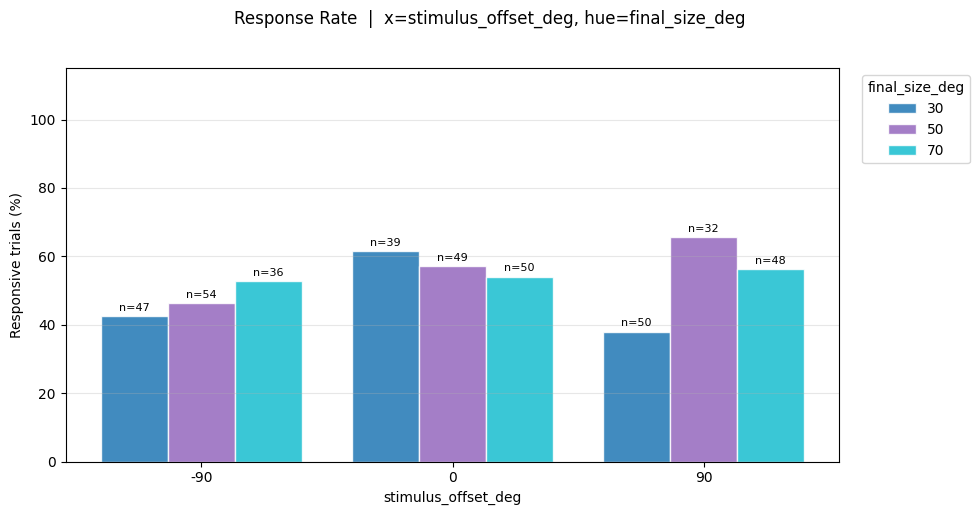

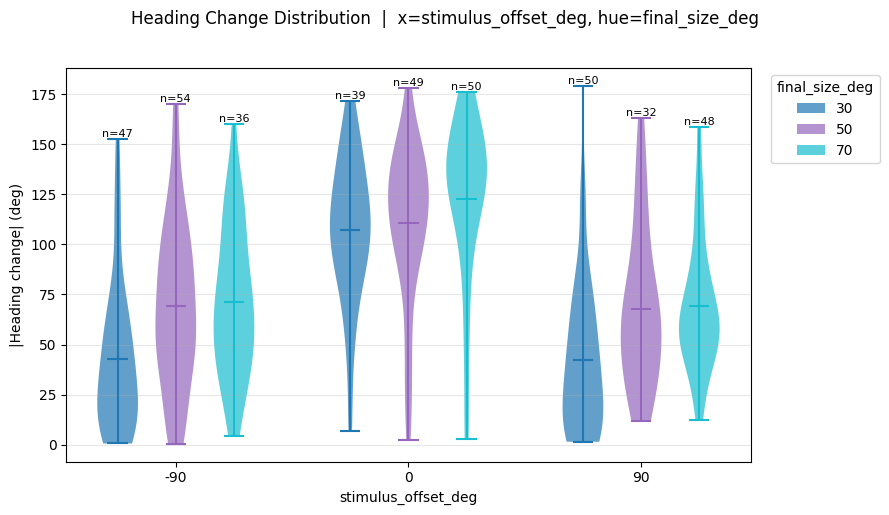

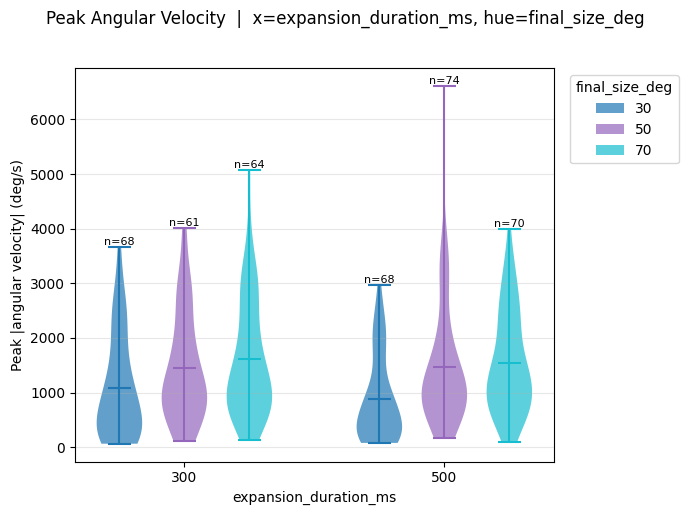

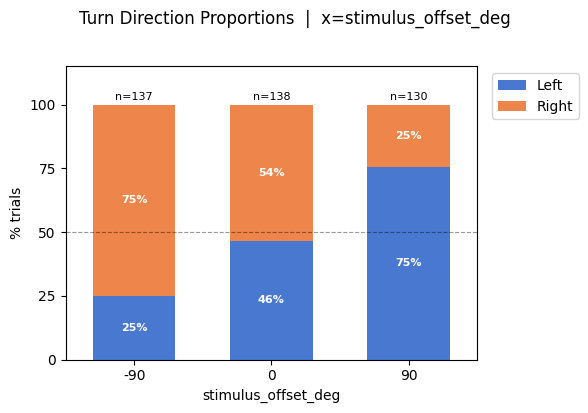

In [8]:
# pre_frames=0 means no pre-stim window, so baseline subtraction has nothing
# to subtract — disable it explicitly to keep the ylabel honest.
fig = plot_responses(
    single_responses,
    row_by="final_size_deg",
    col_by="stimulus_offset_deg",
    hue_by="expansion_duration_ms",
    baseline_subtract=False,
)

# Responsiveness rate: x = stimulus direction, hue = looming size
fig = plot_responsiveness_rates(
    single_responses,
    col_by="stimulus_offset_deg",
    hue_by="final_size_deg",
)

# Heading change distribution: same layout
fig = plot_heading_changes(
    single_responses,
    col_by="stimulus_offset_deg",
    hue_by="final_size_deg",
    absolute=True,
)

# Peak velocity distribution: same layout
fig = plot_peak_velocity(
    responses=single_responses,
    col_by="expansion_duration_ms",
    hue_by="final_size_deg",
)
# Turn direction distribution: same layout, but hue = expansion duration
compute_turn_direction(single_responses)
fig = plot_turn_proportions(responses=single_responses, x_by="stimulus_offset_deg")                                                                                    

## Load data

`file_groups` maps each experimental condition to a list of `.braidz` paths. Every response returned gets a `'group'` key you can later use with `hue_by='group'`.

In [ ]:
file_groups = {
    "CS": [
        "/mnt/data/experiments/20260415_154556.braidz",
    ],
    "DNp03": [
        "/mnt/data/experiments/20260410_143644.braidz",
        "/mnt/data/experiments/20260407_171532.braidz",
    ],
}

responses = process_file_groups(file_groups, pre_frames=-50, post_frames=100)

# All 4 classification methods are computed and stored on every response.
# Thresholds below are the defaults — shown explicitly for easy tuning.
classify_responsiveness(
    responses,
    threshold_deg_s=300,       # used by peak, z-score, and saccade methods
    window_ms=100,              # ±ms around end_expansion_time for detection window
    zscore_k=3.0,               # method 1: SD above pre-stim baseline
    baseline_window_ms=(-400, -100),  # method 1: pre-stim window for baseline stats
    min_duration_ms=30,         # method 3: minimum saccade duration
    max_duration_ms=150,        # method 3: maximum saccade duration
    heading_threshold_deg=30,   # method 2: minimum |heading_change|
    impulse_threshold_deg=20,   # method 4: minimum ∫|ω| dt in window (degrees)
)

## Comparing classification methods

Four criteria are stored on every response dict:

| Field | Method |
|---|---|
| `is_responsive` | Peak `\|ω\|` ≥ threshold in ±window |
| `is_responsive_zscore` | Same peak ≥ k × pre-stim baseline SD |
| `is_responsive_heading` | `\|heading_change\|` ≥ threshold |
| `is_responsive_saccade` | `\|ω\|` above threshold for ≥ min_duration consecutively |
| `is_responsive_impulse` | Total `∫\|ω\| dt` in window ≥ threshold |

The cell below prints how many trials each method labels as responsive.

In [ ]:
criteria = [
    "is_responsive",
    "is_responsive_zscore",
    "is_responsive_heading",
    "is_responsive_saccade",
    "is_responsive_impulse",
]

meta = pl.DataFrame(
    [{k: r[k] for k in criteria} for r in responses]
)

n = len(responses)
print(f"Total trials: {n}\n")
for col in criteria:
    count = meta[col].sum()
    print(f"  {col:<28} {count:>4} / {n}  ({100*count/n:.1f}%)")

## Faceted angular velocity traces

`plot_responses` maps:
- `row_by` → subplot rows
- `col_by` → subplot columns
- `hue_by` → line colors within each subplot

If you have more stimulus parameters than you can fit, pre-filter the list: `[r for r in responses if r['expansion_duration_ms'] == 500]`.

In [ ]:
fig = plot_responses(
    responses,
    row_by="final_size_deg",
    col_by="stimulus_offset_deg",
    hue_by="group",
)

## Responsiveness rates

For bar / violin plots, `col_by` becomes the x-axis tick dimension and `hue_by` gives side-by-side bars/violins within each tick. Use `row_by` to facet by an additional parameter.

In [ ]:
fig = plot_responsiveness_rates(
    responses,
    col_by="stimulus_offset_deg",
    hue_by="group",
)

## Heading change distribution

Violin plot of the net heading change (degrees) per trial. Same `col_by` / `hue_by` semantics as the responsiveness rate plot above. `n` is shown above each violin.

In [ ]:
fig = plot_heading_changes(
    responses,
    col_by="stimulus_offset_deg",
    hue_by="group",
)

## Responsive vs non-responsive traces

`plot_responses_by_responsiveness` splits on the `is_responsive` field.
To use a different criterion, copy it into `is_responsive` before plotting
(and restore it after if you want to keep the original).

Rows are always Responsive / Non-responsive (no `row_by` parameter).
Columns and hue work as in `plot_responses`.

In [ ]:
# Default: split by peak |ω| criterion (is_responsive)
fig = plot_responses_by_responsiveness(
    responses,
    col_by="stimulus_offset_deg",
    hue_by="group",
)

# To split by a different criterion, use a shallow copy so the original
# is_responsive field is not overwritten:
# criterion = "is_responsive_saccade"  # or _zscore / _heading / _impulse
# responses_alt = [{**r, "is_responsive": r[criterion]} for r in responses]
# fig = plot_responses_by_responsiveness(responses_alt, col_by="stimulus_offset_deg", hue_by="group")

## Saccade latency distribution

`saccade_onset_ms` (method 3) records when the saccade started relative to stimulus onset.
Plotting it relative to `end_expansion_time` shows whether flies tend to respond
before, during, or after the looming reaches maximum size.

In [ ]:
groups = {r["group"] for r in responses}
fig, ax = plt.subplots(figsize=(7, 4))

for group in sorted(groups):
    # latency relative to end_expansion_time (positive = after expansion ends)
    latencies = [
        r["saccade_onset_ms"] - r["end_expansion_time"] * 1000
        for r in responses
        if r["group"] == group and not np.isnan(r["saccade_onset_ms"])
    ]
    ax.hist(latencies, bins=30, alpha=0.6, label=group)

ax.axvline(0, color="k", linestyle="--", alpha=0.7, label="end expansion")
ax.set_xlabel("Saccade onset relative to end of expansion (ms)")
ax.set_ylabel("Count")
ax.legend()
ax.set_title("Saccade latency distribution")
fig.tight_layout()